# Lab 5b: Pretraining-Ergebnisse

**Gruppe:** Phillip Graf, Konstantin Schmidt, Fabian Holländer 
 
**Anpassungen und Trainingslauf:** Fabian Holländer

Dieses Notebook dokumentiert den Pretraining-Lauf, der für die Präsentation und den abschließenden Vergleich in Lab 8 verwendet wurde. Es konzentriert sich auf die dafür relevanten Schritte: Rezeptkorpus, Train/Validation-Split, DataLoader, Loss-Berechnung, Training, Checkpoint und kurzer Vergleich mit OpenAI GPT-2.

Verwendeter Checkpoint:

`Abgabe/datasets/pre-training/model_pretrained_r100000_ctx512_e7_val1.44_20260616_074303.pth`

Hinweis: Der Trainingslauf ist rechenintensiv. Die gespeicherten Outputs dokumentieren den ausgeführten Lauf; die Trainingszelle sollte nur erneut ausgeführt werden, wenn der Checkpoint bewusst neu erzeugt werden soll.

## Quellen und Grundlage

- Codebasis: Sebastian Raschka, `rasbt/LLMs-from-scratch`, Kapitel 5, insbesondere Training, Loss-Berechnung, Sampling und GPT-2-Weight-Loading.
- GPT-Modell und DataLoader aus den vorherigen Labs bzw. `Abgabe/utils/gpt.py`.
- Daten: RecipeNLG; die originalen Datenquellen bitte dem [lab1.ipynb](./lab1.ipynb) entnehmen.  Daraus wurden 100000 Rezepte für diesen Lauf verwendet.
- Vergleichsmodell: OpenAI GPT-2 small (124M), geladen über Raschkas `download_and_load_gpt2`-Helper.
- Verwendete Bibliotheken: PyTorch, pandas, matplotlib und tiktoken.

In [13]:
# --- stdlib ---
import ast
import os
import sys

# --- third-party ---
import torch
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- eigene utils (gpt.py im utils-Ordner) ---
sys.path.append(os.path.join(os.getcwd(), "utils"))
from gpt import (
    GPTModel,
    generate,
    generate_text_simple,
    create_dataloader_v1,
    load_weights_into_gpt,
)

## Datensatz laden

Für den Trainingslauf wurden 100000 Rezepte aus der Rezept-CSV verwendet.

In [ ]:
cloud_url = "https://syncandshare.lrz.de/dl/fiHE8nDPcb4nww3VCn4QmN/reduced_dataset_100k.csv"

try:
    print("Lade Datensatz aus der Cloud...")
    df = pd.read_csv(cloud_url).head(100000)
    print("Datensatz erfolgreich geladen!")
    print("Info:")
    print(df.info())
    print("")
    print("Anfang (Head) des Datensatzes:")
    print(df.head())
except Exception as e:
    print(f"Ein Fehler ist beim Laden des Datensatzes aufgetreten: {e}")

Lade Datensatz aus der Cloud...
Datensatz erfolgreich geladen!

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   100000 non-null  int64 
 1   title        100000 non-null  object
 2   ingredients  100000 non-null  object
 3   directions   100000 non-null  object
 4   link         100000 non-null  object
 5   source       100000 non-null  object
 6   NER          100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Anfang (Head) des Datensatzes:
   Unnamed: 0                  title  \
0           0    No-Bake Nut Cookies   
1           1  Jewell Ball'S Chicken   
2           2            Creamy Corn   
3           3          Chicken Funny   
4           4   Reeses Cups(Candy)     

                                         ingredients  \
0  ["1 c. firmly packed brown sugar", "1/2 c. eva...   
1  

## Korpus erzeugen

Jedes Rezept wird als eigenes Dokument formatiert und mit `<|endoftext|>` abgeschlossen.

In [15]:
def to_list(cell):
    if isinstance(cell, list): return cell
    if pd.isna(cell): return []
    try: return ast.literal_eval(cell)
    except (ValueError, SyntaxError): return [str(cell)]

def format_recipe(row):
    title = str(row["title"]).strip()
    ingr  = "\n".join(s.strip() for s in to_list(row["ingredients"]))
    direc = "\n".join(s.strip() for s in to_list(row["directions"]))
    return f"Recipe: {title}\nIngredients:\n{ingr}\nDirections:\n{direc}"

recipes = [format_recipe(r) for _, r in df.iterrows()]
corpus = "".join(r + "<|endoftext|>" for r in recipes)

os.makedirs("datasets/pre-training", exist_ok=True)

with open("datasets/pre-training/corpus.txt", "w", encoding="utf-8") as f:
    f.write(corpus)
print(len(recipes), "Rezepte;", len(corpus), "Zeichen")


100000 Rezepte; 46969894 Zeichen


## Train/Validation-Split

Der Split erfolgt auf Rezeptebene: 90 % Training, 10 % Validierung.

In [16]:
sys.path.append(os.path.join(os.getcwd(), "utils"))
from gpt import GPTDatasetV1, create_dataloader_v1

SEP = "<|endoftext|>"
with open("datasets/pre-training/corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

# auf REZEPT-Ebene splitten (Separator = Grenze), nicht per Zeichen-Index
recipes = [r for r in corpus.split(SEP) if r.strip()]
split_idx = int(0.9 * len(recipes))
train_data = "".join(r + SEP for r in recipes[:split_idx])
val_data   = "".join(r + SEP for r in recipes[split_idx:])

print(f"Rezepte gesamt: {len(recipes)}")
print(f"Training:    {len(recipes[:split_idx])} Rezepte, {len(train_data)} Zeichen")
print(f"Validierung: {len(recipes[split_idx:])} Rezepte, {len(val_data)} Zeichen")

Rezepte gesamt: 100000
Training:    90000 Rezepte, 42288769 Zeichen
Validierung: 10000 Rezepte, 4681125 Zeichen


## DataLoader und Modellkonfiguration

Die Sequenzlänge beträgt 512 Tokens, der Batch enthält 4 Sequenzen. Dadurch verarbeitet ein Batch 2048 Tokens.

In [17]:
GPT_CONFIG = {
    "vocab_size": 50257,     # MUSS zum gpt2-Tokenizer passen (sonst KeyError beim Decoden)
    "context_length": 512,    
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


In [18]:

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break

print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break

Train loader:
torch.Size([4, 512]) torch.Size([4, 512])
Validation loader:
torch.Size([4, 512]) torch.Size([4, 512])


## Loss-Funktionen

Trainings- und Validierungs-Loss werden als Cross-Entropy über die nächsten Token berechnet.

In [19]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
    return total_loss / num_batches

## Initialer Loss

Vor dem Training liegt der Loss erwartbar nahe bei `ln(50257)`, da das Modell noch keine Rezeptstruktur gelernt hat.

In [20]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model = GPTModel(GPT_CONFIG)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 10.96470603942871
Validation loss: 10.97176284790039


## Hilfsfunktionen für Training und Sampling

Diese Funktionen berechnen Losses während des Trainings und erzeugen Beispieltexte nach jeder Epoche.

In [21]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

In [22]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=50, temperature=0.8, top_k=25):
    model.eval()
    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=text_to_token_ids(start_context, tokenizer).to(device),
            max_new_tokens=max_new_tokens,
            context_size=model.pos_emb.weight.shape[0],
            temperature=temperature,   
            top_k=top_k,
        )
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()

## Training

Das Modell wurde für 7 Epochen auf 100000 Rezepten trainiert. Die gespeicherten Logs zeigen den Loss-Verlauf und jeweils einen Beispieltext nach jeder Epoche. Die nicht renderbaren Jupyter-Widget-Progressbars wurden aus den Outputs entfernt; die relevanten Textlogs bleiben erhalten.

Vor dem Training
Recipe:abethnin divineALL ruin Functional habit assigned missing Near Nancy-(busters Presidents patriot foldmentioned remote Claudia Minotaur


Ep 1 (Step 0): Train 8.830 | Val 8.827
Ep 1 (Step 500): Train 2.534 | Val 2.521
Ep 1 (Step 1000): Train 2.221 | Val 2.232
Ep 1 (Step 1500): Train 2.003 | Val 2.083
Ep 1 (Step 2000): Train 1.890 | Val 1.982
Ep 1 (Step 2500): Train 1.891 | Val 1.911
Ep 1 (Step 3000): Train 1.823 | Val 1.855
Ep 1 (Step 3500): Train 1.766 | Val 1.813
Ep 1 (Step 4000): Train 1.691 | Val 1.774
Ep 1 (Step 4500): Train 1.688 | Val 1.753
Ep 1 (Step 5000): Train 1.670 | Val 1.724
Ep 1 (Step 5500): Train 1.624 | Val 1.700
Recipe: Pineapple Pudding Cake Mix Ingredients: 1 box Duncan Hines Butter Recipe supreme cake mix 1 box instant vanilla pudding mix 1 box instant vanilla pudding 3 c. milk 1 large Cool Whip 3 large eggs 1 (


Ep 2 (Step 6000): Train 1.544 | Val 1.680
Ep 2 (Step 6500): Train 1.564 | Val 1.665
Ep 2 (Step 7000): Train 1.591 | Val 1.657
Ep 2 (Step 7500): Train 1.574 | Val 1.639
Ep 2 (Step 8000): Train 1.541 | Val 1.624
Ep 2 (Step 8500): Train 1.488 | Val 1.617
Ep 2 (Step 9000): Train 1.516 | Val 1.610
Ep 2 (Step 9500): Train 1.464 | Val 1.594
Ep 2 (Step 10000): Train 1.411 | Val 1.584
Ep 2 (Step 10500): Train 1.451 | Val 1.576
Ep 2 (Step 11000): Train 1.483 | Val 1.568
Ep 2 (Step 11500): Train 1.416 | Val 1.563
Recipe: Chocolate Chip Cookies Ingredients: 2 1/4 c. flour 1 Tbsp. baking powder 1 tsp. salt 1 1/2 c. shortening 1 c. sugar 2 eggs 1/2 c. milk


Ep 3 (Step 12000): Train 1.466 | Val 1.555
Ep 3 (Step 12500): Train 1.467 | Val 1.552
Ep 3 (Step 13000): Train 1.379 | Val 1.546
Ep 3 (Step 13500): Train 1.425 | Val 1.546
Ep 3 (Step 14000): Train 1.404 | Val 1.537
Ep 3 (Step 14500): Train 1.387 | Val 1.531
Ep 3 (Step 15000): Train 1.360 | Val 1.524
Ep 3 (Step 15500): Train 1.331 | Val 1.524
Ep 3 (Step 16000): Train 1.365 | Val 1.517
Ep 3 (Step 16500): Train 1.381 | Val 1.515
Ep 3 (Step 17000): Train 1.369 | Val 1.508
Ep 3 (Step 17500): Train 1.359 | Val 1.504
Recipe: Chicken Casserole Ingredients: 1 chicken, cooked and deboned 1 small can evaporated milk 1 small onion, chopped 1 c. celery, chopped 8 oz. pkg. Velveeta cheese, sliced 


Ep 4 (Step 18000): Train 1.345 | Val 1.505
Ep 4 (Step 18500): Train 1.328 | Val 1.507
Ep 4 (Step 19000): Train 1.341 | Val 1.504
Ep 4 (Step 19500): Train 1.338 | Val 1.502
Ep 4 (Step 20000): Train 1.322 | Val 1.496
Ep 4 (Step 20500): Train 1.265 | Val 1.499
Ep 4 (Step 21000): Train 1.347 | Val 1.488
Ep 4 (Step 21500): Train 1.316 | Val 1.488
Ep 4 (Step 22000): Train 1.302 | Val 1.478
Ep 4 (Step 22500): Train 1.257 | Val 1.486
Ep 4 (Step 23000): Train 1.290 | Val 1.479
Ep 4 (Step 23500): Train 1.335 | Val 1.478
Recipe: Sweet Potato Casserole Ingredients: 3 c. mashed sweet potatoes 1/3 c. sugar 1/4 c. all-purpose flour 2 eggs, beaten 1/2 c. light brown sugar 1/3


Ep 5 (Step 24000): Train 1.307 | Val 1.486
Ep 5 (Step 24500): Train 1.291 | Val 1.485
Ep 5 (Step 25000): Train 1.282 | Val 1.476
Ep 5 (Step 25500): Train 1.297 | Val 1.477
Ep 5 (Step 26000): Train 1.279 | Val 1.478
Ep 5 (Step 26500): Train 1.258 | Val 1.475
Ep 5 (Step 27000): Train 1.293 | Val 1.474
Ep 5 (Step 27500): Train 1.233 | Val 1.471
Ep 5 (Step 28000): Train 1.229 | Val 1.465
Ep 5 (Step 28500): Train 1.244 | Val 1.463
Ep 5 (Step 29000): Train 1.258 | Val 1.464
Ep 5 (Step 29500): Train 1.269 | Val 1.458
Recipe: Cabbage And Apple Salad Ingredients: 1 head cabbage 1 red apple 1/2 apple 2 apples 1 cucumber 1 head cabbage 1 small bottle mayonnaise Directions: Cook cabbage until tender. 


Ep 6 (Step 30000): Train 1.236 | Val 1.472
Ep 6 (Step 30500): Train 1.232 | Val 1.473
Ep 6 (Step 31000): Train 1.304 | Val 1.473
Ep 6 (Step 31500): Train 1.216 | Val 1.467
Ep 6 (Step 32000): Train 1.177 | Val 1.466
Ep 6 (Step 32500): Train 1.209 | Val 1.458
Ep 6 (Step 33000): Train 1.185 | Val 1.457
Ep 6 (Step 33500): Train 1.188 | Val 1.458
Ep 6 (Step 34000): Train 1.203 | Val 1.451
Ep 6 (Step 34500): Train 1.248 | Val 1.447
Ep 6 (Step 35000): Train 1.209 | Val 1.445
Recipe: Chocolate Pie Ingredients: 1 c. white sugar 2 Tbsp. cocoa 1 Tbsp. cornstarch 1/2 tsp. salt 2 Tbsp. cornstarch 3 Tbsp. cocoa 2 c.


Ep 7 (Step 35500): Train 1.171 | Val 1.455
Ep 7 (Step 36000): Train 1.164 | Val 1.463
Ep 7 (Step 36500): Train 1.198 | Val 1.464
Ep 7 (Step 37000): Train 1.231 | Val 1.464
Ep 7 (Step 37500): Train 1.210 | Val 1.457
Ep 7 (Step 38000): Train 1.164 | Val 1.459
Ep 7 (Step 38500): Train 1.166 | Val 1.453
Ep 7 (Step 39000): Train 1.184 | Val 1.451
Ep 7 (Step 39500): Train 1.178 | Val 1.456
Ep 7 (Step 40000): Train 1.190 | Val 1.450
Ep 7 (Step 40500): Train 1.209 | Val 1.445
Ep 7 (Step 41000): Train 1.198 | Val 1.447
Recipe: No-Bake Cookies Ingredients: 1/4 c. cocoa 1/2 c. milk 1/4 c. peanut butter 1 tsp. vanilla 2 c. quick oats Directions: Mix together cocoa,

Bestes Modell wiederhergestellt (Val-Loss 1.445).
Nach Training
Recipe:
Ingredients:
1 (9-inch) unbaked pastry shell
1 (6 oz.)


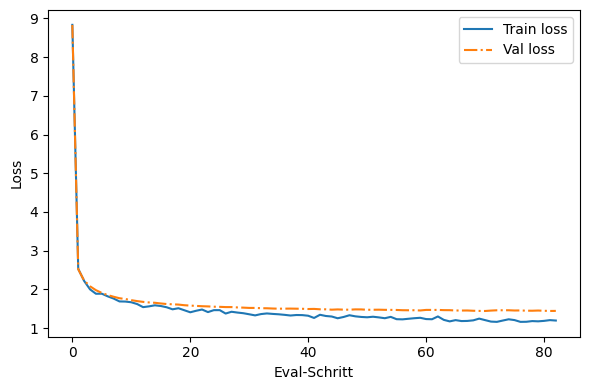

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    best_val_loss = float("inf")          # Early Stopping
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in tqdm(train_loader, desc=f"Epoche {epoch+1}/{num_epochs}"):
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # Grad-Clipping
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                tqdm.write(f"Ep {epoch+1} (Step {global_step}): Train {train_loss:.3f} | Val {val_loss:.3f}")

                if val_loss < best_val_loss:                                    # Early Stopping: bestes Modell merken
                    best_val_loss = val_loss
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        generate_and_print_sample(model, tokenizer, device, start_context)

    if best_state is not None:                                                  # bestes statt letztes Modell behalten
        model.load_state_dict(best_state)
        print(f"\nBestes Modell wiederhergestellt (Val-Loss {best_val_loss:.3f}).")
    return train_losses, val_losses, track_tokens_seen


tokenizer = tiktoken.get_encoding("gpt2")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# Vor Training
print("Vor dem Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recipe:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

num_epochs = 7
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=500, eval_iter=20,
    start_context="Recipe:", tokenizer=tokenizer
)
# Nach Training
print("Nach Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recipe:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

# Plot einmal am Ende (ohne clear_output -> Log + Plot bleiben sichtbar)
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, linestyle="-.", label="Val loss")
plt.xlabel("Eval-Schritt"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()

## Loss-Verlauf

Training- und Validation-Loss sinken beide stark und über den Großteil des Trainings kontinuierlich. Der Validation-Loss erreicht sein bestes gespeichertes Ergebnis bei
  etwa 1.445 und liegt am Ende mit etwa 1.447 fast auf demselben Niveau. Die Lücke zwischen Training- und Validation-Loss bleibt dabei insgesamt stabil und wird erst gegen Ende nur leicht größer. 

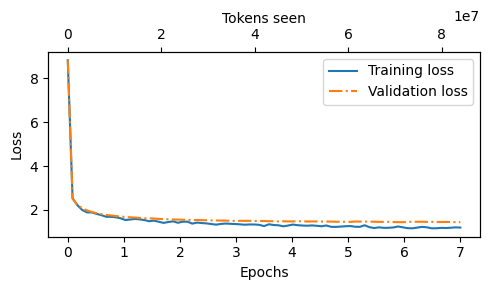

In [25]:
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Checkpoint

Der folgende Checkpoint wurde für den späteren Vergleich in Lab 8 verwendet.

In [30]:
MODEL_PATH = "datasets/pre-training/model_pretrained_r100000_ctx512_e7_val1.44_20260616_074303.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "num_epochs": num_epochs,
}, MODEL_PATH)
print(f"Modell gespeichert: {MODEL_PATH}")

Modell gespeichert: datasets/pre-training/model_pretrained_r100000_ctx512_e7_val1.44_20260616_074303.pth


## OpenAI GPT-2 laden

Als Referenz wird GPT-2 small (124M) in dieselbe GPT-Architektur geladen. Der Abschnitt dient nur der qualitativen Textgenerierung nach Raschkas Weight-Loading-Schritt.

In [31]:
from gpt_download import download_and_load_gpt2

# Lädt den GPT-2-small-Checkpoint (124M) — gleiche Architektur wie unser Modell
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

# Config exakt nach GPT-2-small (Abweichungen zum Trainingsmodell markiert)
GPT2_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,   # GPT-2: 1024 (nicht 512!) — sonst Shape-Mismatch bei pos_emb
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,         # nur Eval
    "qkv_bias": True,         # GPT-2 hat Attention-Bias -> MUSS True sein
}

gpt2 = GPTModel(GPT2_CONFIG)
load_weights_into_gpt(gpt2, params)   # OpenAI-Gewichte in unsere Architektur kopieren
gpt2.to(device)
gpt2.eval()
print("GPT-2 (124M) geladen.")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
GPT-2 (124M) geladen.


## Textvergleich mit OpenAI GPT-2

Beide Modelle generieren mit demselben Startkontext. Dieser Abschnitt dient nur als qualitative Referenz nach dem Laden der OpenAI-GPT-2-Gewichte.

In [ ]:
print("Textvergleich")
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
print("Unser Modell:")
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Recipe: Chocolate Cake\nIngredients:", tokenizer).to(device),
    max_new_tokens=50,
    context_size=GPT_CONFIG["context_length"],
    top_k=25,
    temperature=1.0
)
print(token_ids_to_text(token_ids, tokenizer))

print("\nOpenAI GPT-2:")
torch.manual_seed(123)
token_ids = generate(
    model=gpt2,
    idx=text_to_token_ids("Recipe: Chocolate Cake\nIngredients:", tokenizer).to(device),
    max_new_tokens=50,
    context_size=GPT2_CONFIG["context_length"],
    top_k=25,
    temperature=1.0,
    eos_id=eot_id
)
print(token_ids_to_text(token_ids, tokenizer))

Textvergleich
Unser Modell:
Recipe: Chocolate Cake
Ingredients:
2 3/4 c. all-purpose flour
1 1/2 c. sugar
1/4 c. cocoa
1/2 tsp. baking soda
1 3/4 tsp. baking powder
1/4 tsp. salt

OpenAI GPT-2:
Recipe: Chocolate Cake
Ingredients:
For the filling:
Creamy almond milk, 2 tbsp. cold water, 1 tsp. vanilla extract
Directions:
For the buttercream icing:
Use 2 tbsp. of buttercream icing mix (I use 1 tbsp.


## Kurzfazit

Der Trainingslauf zeigt, dass das Modell die formale Rezeptstruktur deutlich lernt: Der Loss sinkt von ca. 10.97 auf ca. 1.20, der beste Validation-Loss liegt bei ca. 1.445. Die generierten Texte enthalten Rezepttitel, Zutatenlisten und teilweise Zubereitungsschritte, bleiben inhaltlich aber begrenzt plausibel und wiederholen Muster. OpenAI GPT-2 wird hier nur als qualitative Referenz nach dem Laden der vortrainierten Gewichte verwendet. Der gespeicherte Checkpoint dient als eigene Pretraining-Basis für den späteren Vergleich in Lab 8.